<h1 style="color:#3E5F36; border-bottom: 3px solid #8FAD6D; padding-bottom: 6px;"> EDA — Trazos y Hojas</h1>
> Análisis exploratorio: correlación de categorías con horas de venta y análisis del canal Glovo

**Periodo:** 1 de enero – 8 de mayo de 2026
**Datasets utilizados:** `compras_tpv.csv` · `ventas_glovo.csv` · `cierre_caja.csv` · `agrupacion_horas.csv`


In [ ]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.stats import chi2_contingency, mannwhitneyu

# ── Paleta corporativa ────────────────────────────────────────────────────────
C_PRINCIPAL = '#3E5F36'   # Verde bosque
C_TIERRA    = '#8B7355'   # Marrón tierra
C_HOJA      = '#8FAD6D'   # Verde hoja suave
C_BEIGE     = '#F2EBDD'   # Beige papel
C_BLANCO    = '#FAF8F2'   # Blanco roto

plt.rcParams.update({
    'figure.facecolor':  C_BLANCO,
    'axes.facecolor':    C_BEIGE,
    'axes.edgecolor':    C_TIERRA,
    'axes.labelcolor':   C_PRINCIPAL,
    'axes.titlecolor':   C_PRINCIPAL,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     12,
    'axes.grid':         True,
    'grid.color':        '#D6CCBB',
    'grid.linewidth':    0.6,
    'text.color':        C_PRINCIPAL,
    'xtick.color':       C_TIERRA,
    'ytick.color':       C_TIERRA,
    'legend.facecolor':  C_BEIGE,
    'legend.edgecolor':  C_TIERRA,
})

print('Librerías e importaciones listas')


✅ Librerías e importaciones listas


In [2]:
sys.path.append(str(Path('../utils').resolve()))

from funciones_eda import (cardinalidad, plot_categorical_relationship_fin,
    pinta_distribucion_categoricas, plot_combined_graphs,
    grafico_dispersion_con_correlacion, plot_categorical_numerical_relationship)


<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">1. Carga y preparación de datos</h2>

In [3]:
agrupacion_horas = pd.read_csv("../data/agrupacion_horas.csv", sep=None, engine='python')
cierre_caja      = pd.read_csv("../data/cierre_caja.csv",      sep=None, engine='python')
compras_tpv      = pd.read_csv("../data/compras_tpv.csv",      sep=None, engine='python')
ventas_glovo     = pd.read_csv("../data/ventas_glovo.csv",     sep=None, engine='python')

# Limpiar BOM y espacios en nombres de columnas
for df in [cierre_caja, compras_tpv, ventas_glovo]:
    df.columns = df.columns.str.replace('\ufeff', '', regex=False).str.strip()

# Copias de trabajo
horas  = agrupacion_horas.copy()
cierre = cierre_caja.copy()
ventas = compras_tpv.copy()
glovo  = ventas_glovo.copy()

print('✅ Datos cargados correctamente')


✅ Datos cargados correctamente


In [4]:
# Rellenar nulos en Categoría
ventas['Categoría'] = ventas['Categoría'].fillna('Acceso Rapido')

# Eliminar columnas sin datos útiles
ventas.drop(columns=["Código Fiscal", "Nominal", "A/C Ref", "Notas",
                      "Identificación del Cliente", "Motivo del Descuento"],
            inplace=True)

# Extraer hora de la fecha/hora
ventas['Hora'] = pd.to_datetime(ventas['Fecha/Hora'], dayfirst=True).dt.hour

print(f'ventas: {ventas.shape}')
print(f'glovo:  {glovo.shape}')


ventas: (7615, 15)
glovo:  (59, 12)


<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">2. Diccionario de datos</h2>

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Dataset: `cierre_caja.csv`</h3>
**Descripción:** Total de ventas diarias con métricas de caja, devoluciones y márgenes
**Periodo:** 1 de enero – 8 de mayo de 2026

| Nombre del campo  | Descripción                                      | Tipo de variable     | Notas                                              |
|-------------------|--------------------------------------------------|----------------------|----------------------------------------------------|
| Date              | Fecha del cierre de caja                         | Fecha                | Formato DD/MM/YYYY, 94 días de datos               |
| NoOfTrans         | Número de transacciones del día                  | Numérica Discreta    | Media 37, máximo 66                                |
| RefundQty         | Unidades devueltas en el día                     | Numérica Discreta    | Máximo 121 uds en un día                           |
| RefundValue       | Valor económico de las devoluciones (€)          | Numérica Continua    | Máximo 31.35€                                      |
| NoSaleQty         | Aperturas de caja sin venta                      | Numérica Discreta    | Casi siempre 0                                     |
| VoidLineQty       | Líneas de venta anuladas en el día               | Numérica Discreta    | Máximo 280                                         |
| VoidLineValue     | Valor de las líneas anuladas (€)                 | Numérica Continua    | Máximo 202.78€                                     |
| ItemQty           | Total de artículos vendidos en el día            | Numérica Discreta    | Media 275, máximo 1.016                            |
| ValueIncVAT       | Ventas totales del día con IVA (€)               | Numérica Continua    | Media 181.3€, máximo 410.72€                       |
| Margin            | Margen bruto total del día (€)                   | Numérica Continua    | Media 87.7€, máximo 211.11€                        |
| MarginPerc        | Porcentaje de margen sobre ventas                | Numérica Continua    | Media 53.2%, máximo 75.6%                          |


In [5]:
cierre_caja.head(5)

,Date,NoOfTrans,RefundQty,RefundValue,NoSaleQty,VoidLineQty,VoidLineValue,ItemQty,Value,Discount,AvgValueIncVAT,ValueIncVAT,ValueExcVAT,AvgMargin,Margin,MarginPerc
0,08/05/2026 5:00:00,46,0,0.00,0,88,202.78,381,400.11,1.26,8.67,398.85,331.35,2.53,116.47,0.3515
1,07/05/2026 5:00:00,36,0,0.00,0,119,181.65,443,410.72,0.00,11.41,410.72,339.40,3.14,113.08,0.3332
2,06/05/2026 5:00:00,42,121,19.81,0,132,112.33,352,168.13,0.00,4.00,168.13,138.89,1.95,81.69,0.5882
3,05/05/2026 5:00:00,44,0,0.00,0,17,38.04,284,287.49,-1.70,6.57,289.19,239.62,2.68,118.13,0.4930
4,04/05/2026 5:00:00,50,6,1.00,0,26,11.30,455,266.88,-1.30,5.36,268.18,223.01,2.65,132.71,0.5951


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Dataset: `compras_tpv.csv`</h3>
**Descripción:** Líneas de venta individuales registradas en el TPV con detalle de producto, categoría y método de pago
**Periodo:** 1 de enero – 8 de mayo de 2026

| Nombre del campo                               | Descripción                                      | Tipo de variable     | Notas                                              |
|------------------------------------------------|--------------------------------------------------|----------------------|----------------------------------------------------|
| Producto                                       | Nombre del producto vendido                      | Categórica           | 7.615 líneas de venta                              |
| Cantidad                                       | Unidades vendidas en la línea                    | Numérica Continua    | Puede ser negativo (devoluciones)                  |
| Categoría                                      | Categoría del producto                           | Categórica           | 302 valores nulos → imputados como 'Acceso Rapido' |
| Fecha/Hora                                     | Fecha y hora de la transacción                   | Fecha                | Formato DD/MM/YYYY HH:MM:SS                        |
| Ventas NETAS                                   | Importe neto de la venta (€)                     | Numérica Continua    | Media 1.94€, máximo 123.97€                        |
| Margen                                         | Margen bruto de la línea (€)                     | Numérica Continua    | Media 1.08€, puede ser negativo                    |
| Método de Pago                                 | Canal de pago utilizado                          | Categórica           | Tarjeta, Efectivo, Credit, Glovo, Mixto            |
| Comida para consumir en el Lugar o para Llevar | Indica el canal de venta                         | Categórica           | Eat in = tienda física / Take Out = Glovo          |
| Hora                                           | Hora extraída de Fecha/Hora                      | Numérica Discreta    | Variable creada en el EDA                          |


In [6]:
ventas.head(5)

,Producto,Cantidad,Categoría,Fecha/Hora,Valor del Descuento,Ventas NETAS,Comida para consumir en el Lugar o para Llevar,Opción de Comer,Impuesto,Ventas TOTALES,Precio de Coste,Margen,Método de Pago,ProductId,Hora
0,Panini Cromos Mundial 2026,1.0,Otros,08/05/2026 19:57:01,0.0,1.24,Eat in,0,0.26,1.5,1.0071,0.2329,Efectivo,2336673,19
1,Panini Cromos Mundial 2026,5.0,Otros,08/05/2026 19:54:52,0.0,6.20,Eat in,0,1.30,7.5,5.0355,1.1645,Tarjeta,2336673,19
2,Azul Soft Fun 1.6,1.0,Bolígrafos,08/05/2026 19:40:49,0.0,0.58,Eat in,0,0.12,0.7,0.1800,0.4000,Efectivo,2155714,19
3,Azul Soft Fun 1.6,1.0,Bolígrafos,08/05/2026 19:40:49,0.0,0.58,Eat in,0,0.12,0.7,0.1800,0.4000,Efectivo,2155714,19
4,Panini Cromos Mundial 2026,1.0,Otros,08/05/2026 19:26:40,0.0,1.24,Eat in,0,0.26,1.5,1.0071,0.2329,Efectivo,2336673,19


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Dataset: `ventas_glovo.csv`</h3>
**Descripción:** Ventas realizadas a través del canal Glovo con detalle de producto, precio y margen
**Periodo:** 1 de enero – 8 de mayo de 2026

| Nombre del campo  | Descripción                                      | Tipo de variable     | Notas                                              |
|-------------------|--------------------------------------------------|----------------------|----------------------------------------------------|
| Name              | Nombre del producto                              | Categórica           | 59 productos distintos en Glovo                    |
| Category          | Categoría del producto                           | Categórica           | Categorías propias de Glovo                        |
| Price             | Precio de venta unitario (€)                     | Numérica Continua    | Media 4.30€, máximo 15.45€                         |
| Qty               | Unidades vendidas                                | Numérica Discreta    | Media 2.4, máximo 9                                |
| SalesIncVAT       | Ventas totales con IVA (€)                       | Numérica Continua    | Media 11.4€, máximo 63.35€                         |
| Margin            | Margen bruto (€)                                 | Numérica Continua    | Media 5.15€, puede ser negativo                    |
| MarginPercent     | Porcentaje de margen sobre ventas                | Numérica Continua    | Media 52.4%, máximo 100%                           |


In [7]:
glovo.head(5)

,Name,Description,Category,Price,Qty,SalesIncVAT,Discount,NetIncVAT,NetExcVAT,TotalCost,Margin,MarginPercent
0,5 Boligrafos Bic Cristal,5 Boligrafos Bic Cristal,BIC,0.00,3,0.00,-6.75,6.75,6.75,8.25,-1.50,-0.2222
1,5 Boligrafos Bic Cristal Medium,5 Boligrafos Bic Cristal Medium,BIC,2.25,1,2.25,0.00,2.25,1.86,0.00,1.86,1.0000
2,Afilador Faber-Castell deposito trans,Afilador Faber-Castell deposito trans,Afilador,2.00,2,4.00,0.00,4.00,3.31,0.94,2.37,0.7160
3,Bloc Cartulina Praxton,Bloc Cartulina Praxton,Blocs,4.00,9,36.00,0.00,36.00,29.79,5.22,24.57,0.8248
4,Bloc de Charol Praxton 10H,Bloc de Charol Praxton 10H,Blocs,2.30,6,13.80,0.00,13.80,11.40,2.10,9.30,0.8158


---
<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">3. Análisis: Categoría de producto × Hora de venta</h2>

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">3.1 Heatmap — Ventas por categoría y hora</h3>

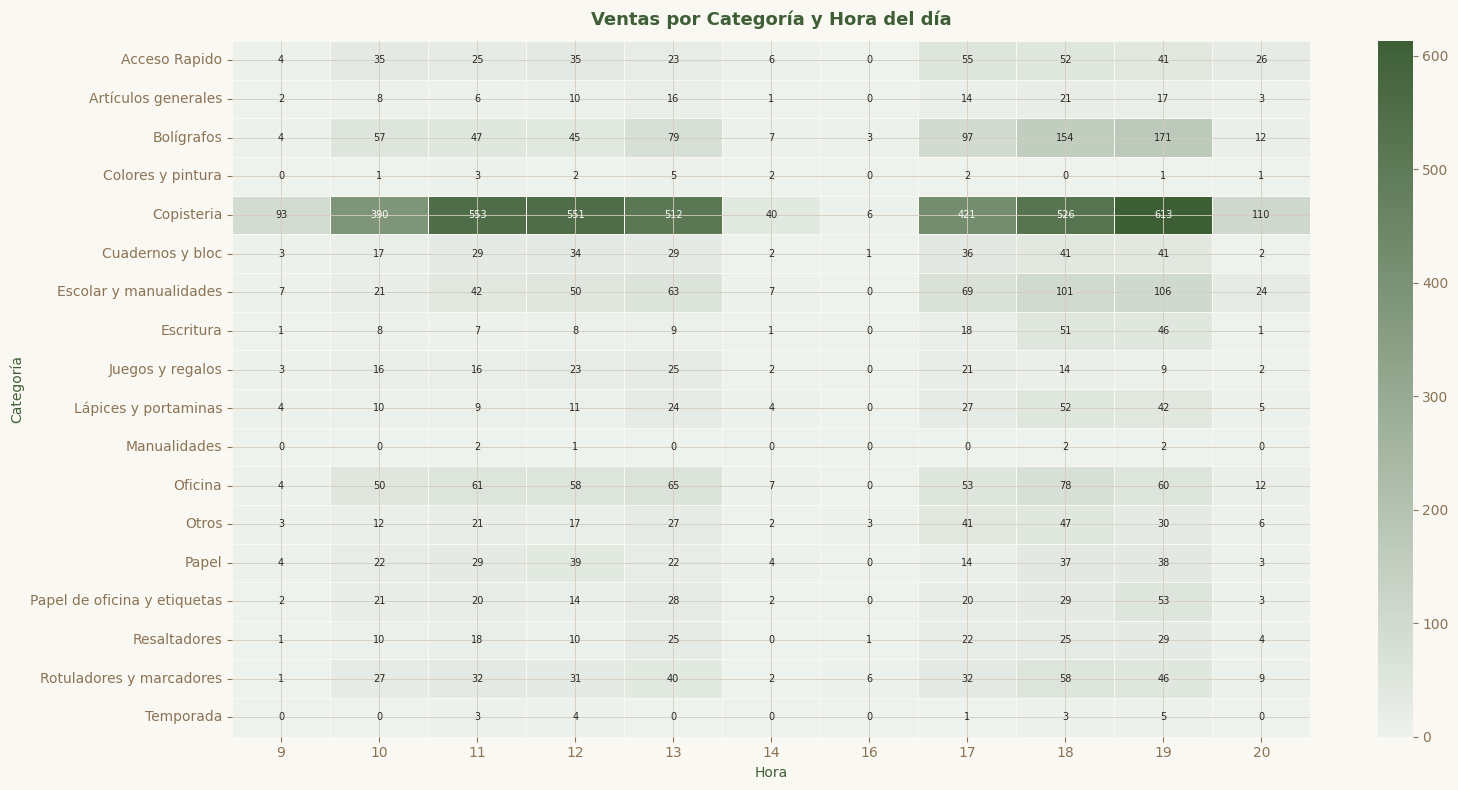

In [8]:
pivot = pd.crosstab(ventas['Categoría'], ventas['Hora'])

cmap_custom = sns.light_palette(C_PRINCIPAL, as_cmap=True)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, cmap=cmap_custom, annot=True, fmt='d', linewidths=0.5,
            linecolor=C_BLANCO, annot_kws={'size': 7})
plt.title('Ventas por Categoría y Hora del día')
plt.xlabel('Hora')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">3.2 Heatmap — Sin Copistería (detalle del resto de categorías)</h3>

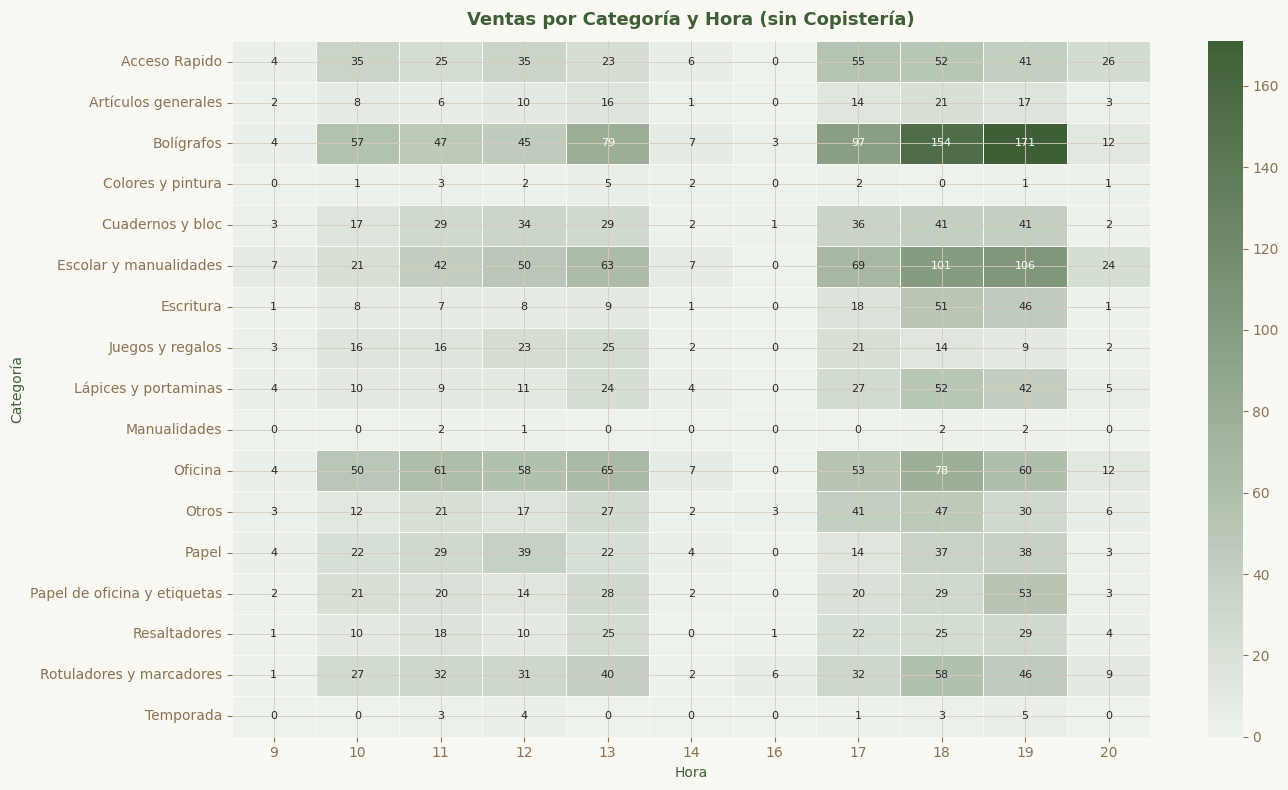

In [9]:
pivot_sin_copia = pivot[~pivot.index.str.contains('Copisteria|Copistería')]

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_sin_copia, cmap=cmap_custom, annot=True, fmt='d',
            linewidths=0.5, linecolor=C_BLANCO, annot_kws={'size': 8})
plt.title('Ventas por Categoría y Hora (sin Copistería)')
plt.xlabel('Hora')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">3.3 Distribución de ventas por categoría</h3>

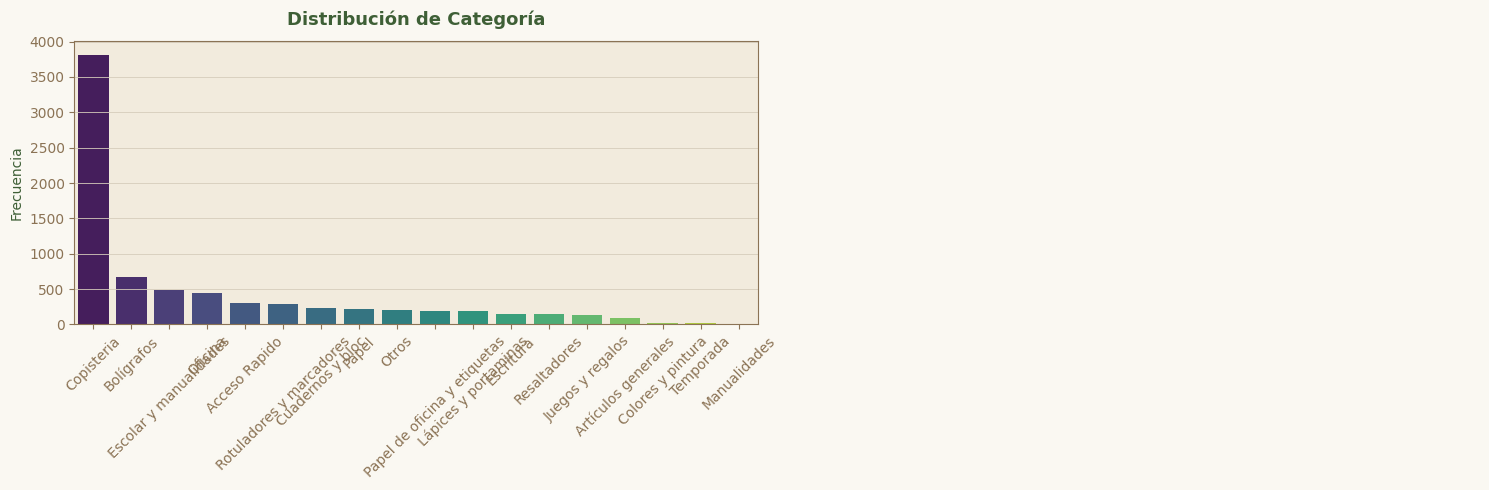

In [10]:
pinta_distribucion_categoricas(ventas, ['Categoría'])

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">3.4 Test Chi-cuadrado — ¿Existe relación estadística?</h3>

In [11]:
chi2, p_valor, gl, esperados = chi2_contingency(pivot)
print(f'Chi-cuadrado: {chi2:.2f}')
print(f'P-valor:      {p_valor:.6f}')

if p_valor < 0.05:
    print('\n✅ Sí hay relación significativa entre categoría y hora')
else:
    print('\n❌ No hay relación significativa')


Chi-cuadrado: 572.87
P-valor:      0.000000

✅ Sí hay relación significativa entre categoría y hora


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">3.5 Cramér's V — Fuerza de la relación</h3>

In [12]:
n = pivot.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(pivot.shape) - 1)))
print(f"Cramér's V: {cramers_v:.3f}")

if cramers_v < 0.1:
    print('Relación muy débil o inexistente')
elif cramers_v < 0.3:
    print('Relación débil')
elif cramers_v < 0.5:
    print('Relación moderada')
else:
    print('Relación fuerte')


Cramér's V: 0.087
Relación muy débil o inexistente


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">3.6 Hora pico por categoría</h3>

In [13]:
hora_pico = (ventas.groupby('Categoría')['Hora']
             .agg(lambda x: x.value_counts().idxmax())
             .reset_index()
             .rename(columns={'Hora': 'Hora pico'}))
hora_pico


,Categoría,Hora pico
0,Acceso Rapido,17
1,Artículos generales,18
2,Bolígrafos,19
3,Colores y pintura,13
4,Copisteria,19
5,Cuadernos y bloc,19
6,Escolar y manualidades,19
7,Escritura,18
8,Juegos y regalos,13
9,Lápices y portaminas,18


<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">Conclusiones: Categoría × Hora</h2>

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Estadísticas</h3>
- La relación entre categoría y hora existe pero es muy débil (Cramér's V = 0.087). La hora del día no determina qué categoría se compra.

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Comportamiento general</h3>
- Todas las categorías siguen el mismo patrón bimodal: mañana (10-13h) y tarde (17-19h). El negocio tiene dos picos claros independientemente de lo que se compre.

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Por categoría</h3>
- **Bolígrafos y Escolar** se compran más por la tarde, posiblemente estudiantes que vienen después del colegio.
- **Oficina** es más de mañana, posiblemente trabajadores que pasan antes o durante su jornada.
- **Manualidades** tiene volumen tan bajo que no hay patrón claro.

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Implicaciones para el negocio</h3>
- No tiene sentido hacer promociones por categoría según la hora porque el comportamiento es demasiado uniforme.
- Sí tendría sentido reforzar el personal en los picos de 12h y 19h.
- El hueco de 14-16h es una oportunidad: si hay demanda perdida en ese horario, abrir podría incrementar ventas especialmente en Oficina.


---
<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">4. Análisis canal Glovo</h2>

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">4.1 Calidad del dataset</h3>

In [14]:
print('Nulos:')
print(glovo.isnull().sum())
print(f'\nDuplicados: {glovo.duplicated().sum()}')
print(f'\nShape: {glovo.shape}')


Nulos:
Name             0
Description      1
Category         0
Price            0
Qty              0
SalesIncVAT      0
Discount         0
NetIncVAT        0
NetExcVAT        0
TotalCost        0
Margin           0
MarginPercent    0
dtype: int64

Duplicados: 0

Shape: (59, 12)


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">4.2 Distribución de variables numéricas</h3>

(5, 2)


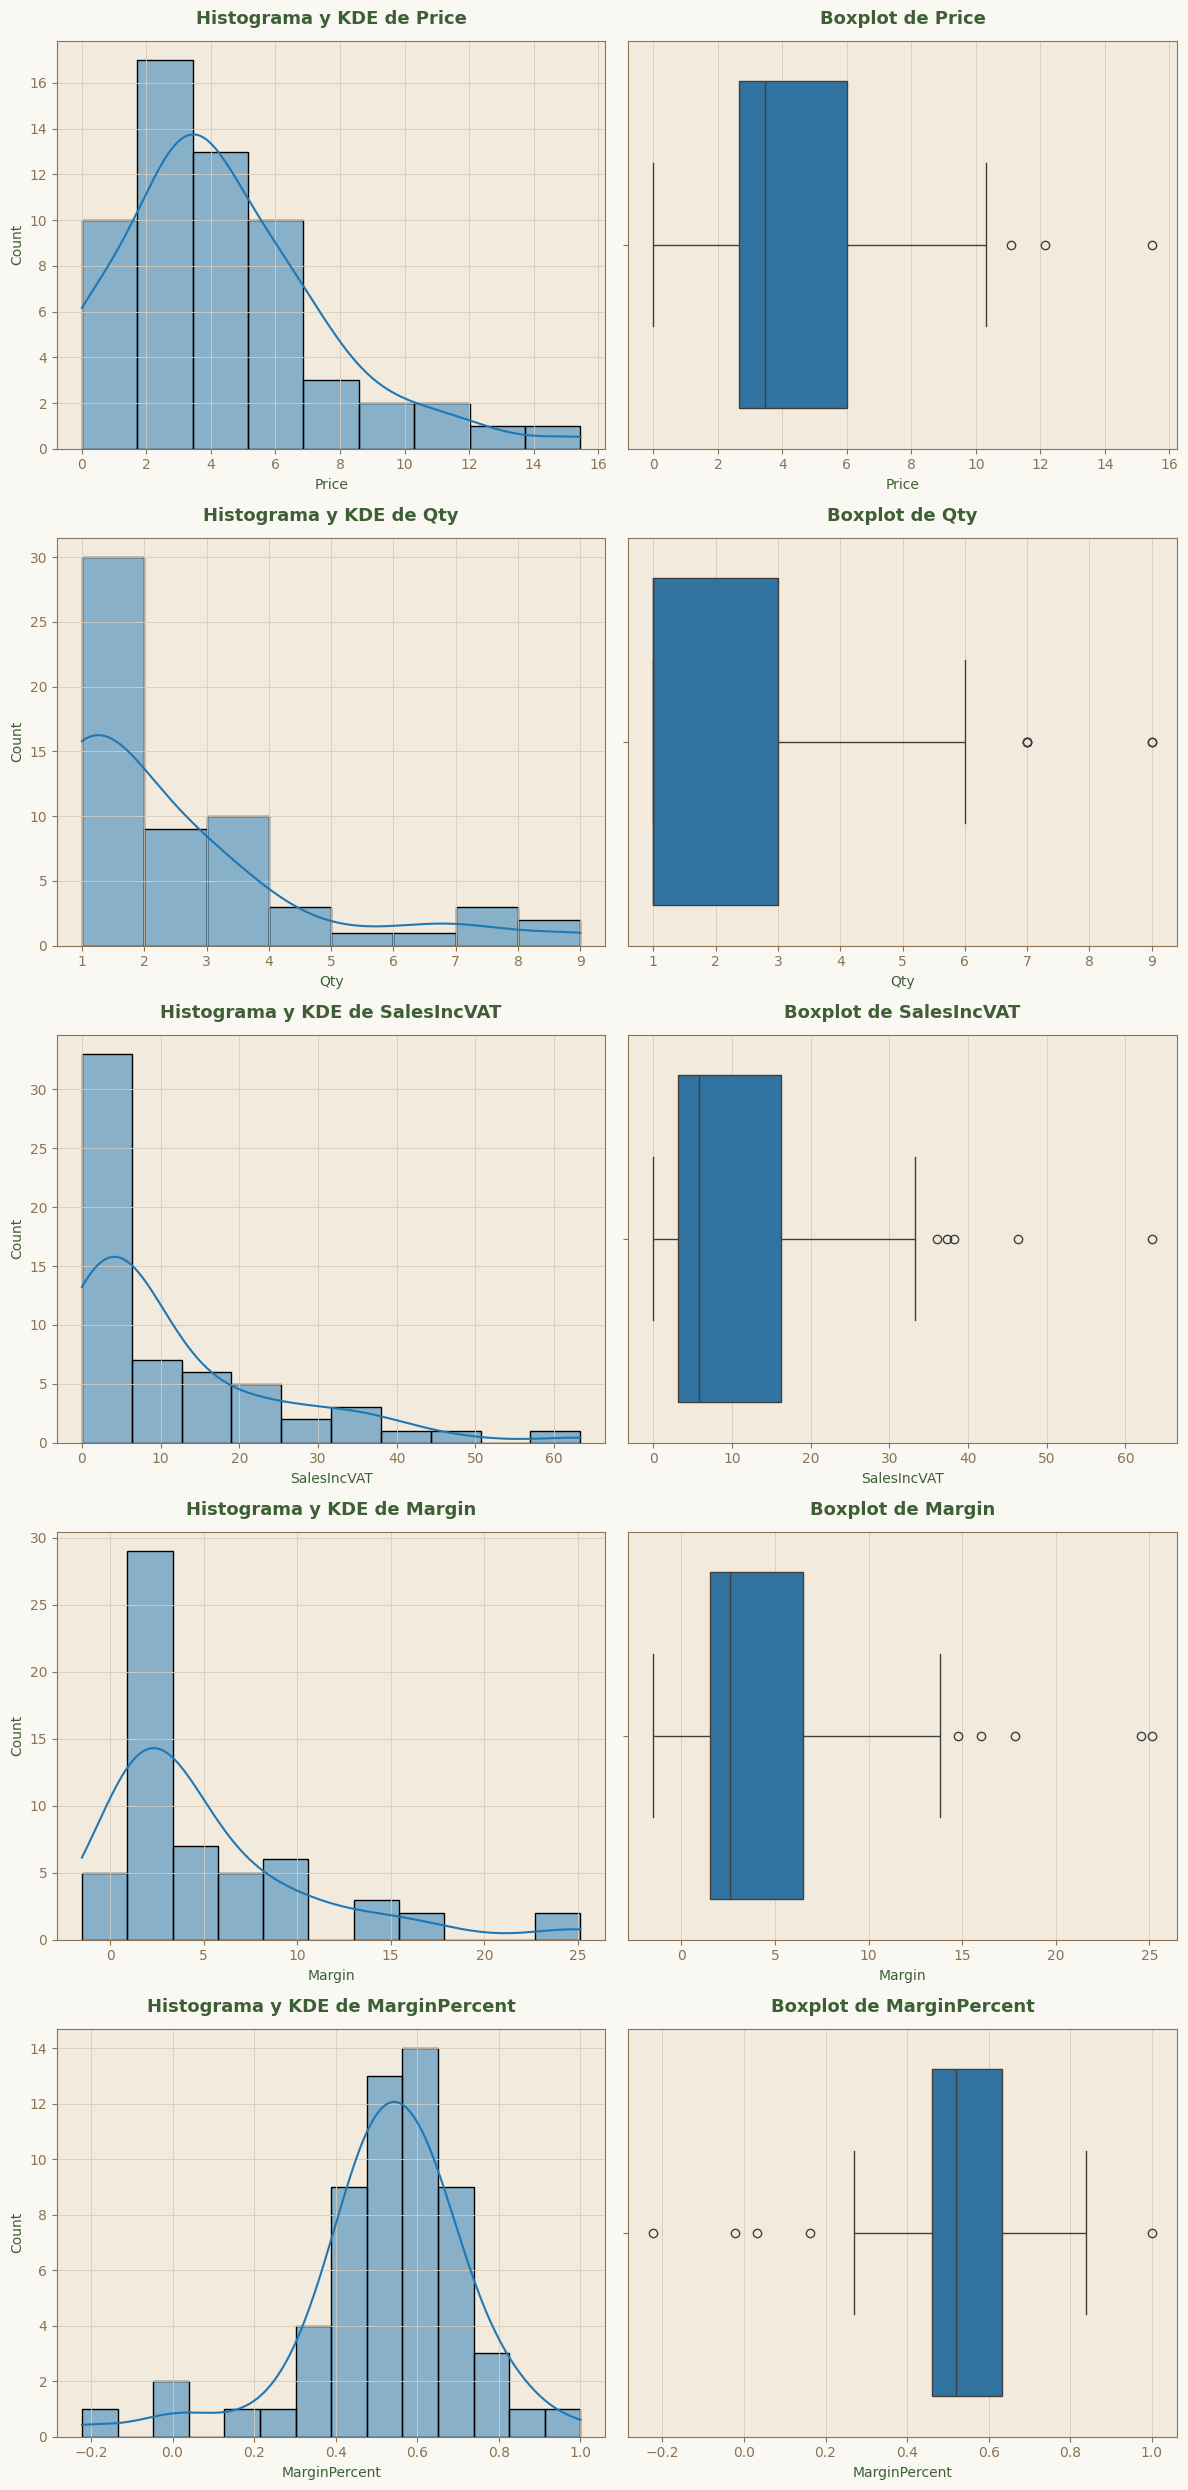

In [15]:
plot_combined_graphs(glovo, ['Price', 'Qty', 'SalesIncVAT', 'Margin', 'MarginPercent'])

<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">Análisis de variables numéricas — Glovo</h2>

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Price (Precio)</h3>
- Catálogo de bajo precio, la mayoría entre 1€ y 6€.
- Distribución sesgada a la derecha con 3 outliers por encima de 8€.

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Qty (Cantidad vendida)</h3>
- Volumen muy bajo, la mayoría de productos se venden entre 1 y 3 unidades.
- 2 outliers destacados con 7 y 9 unidades vendidas.

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">SalesIncVAT (Ventas totales)</h3>
- La mayoría de productos generan menos de 10€ en ventas totales.
- Distribución muy sesgada, con outliers que llegan a 60€.

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Margin (Margen bruto €)</h3>
- Márgenes absolutos bajos, la mayoría entre 0€ y 5€ por producto.
- Outliers que llegan a 25€, probablemente los productos con más unidades vendidas.


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">4.3 Distribución por categoría</h3>

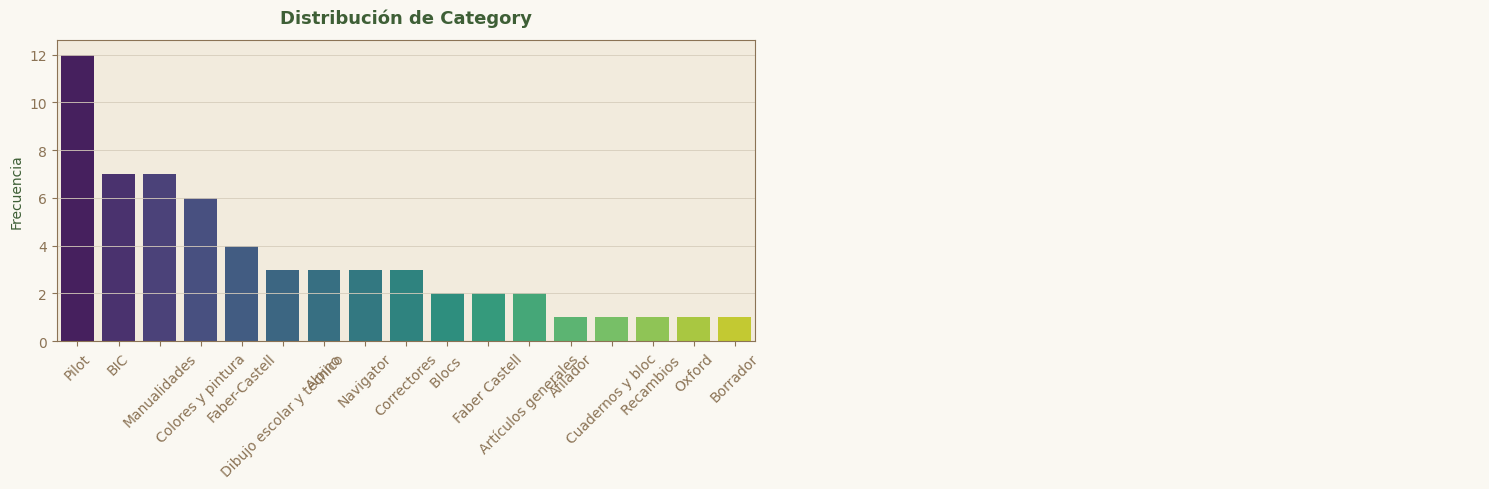

In [16]:
pinta_distribucion_categoricas(glovo, ['Category'])

<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">Análisis de categorías — Glovo</h2>

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Categorías más representadas</h3>
- **Pilot** es la categoría con más productos (12), seguida de **BIC** y **Manualidades** (7 cada una).
- **Colores y pintura** y **Faber-Castell** tienen 6 productos cada una.
- El resto de categorías tienen muy poca presencia, con 1-3 productos.

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Conclusiones</h3>
- El catálogo de Glovo está muy orientado a **material de escritura** (Pilot, BIC, Faber-Castell) y **manualidades**.
- Hay una ausencia notable de copistería, que es el motor del negocio en TPV. Tiene sentido porque copistería no se puede hacer a domicilio.
- Categorías como **Blocs, Cuadernos, Correctores** tienen muy poca presencia, podría ser una oportunidad para ampliar el catálogo.


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">4.4 Top 10 productos más vendidos</h3>

In [17]:
glovo.sort_values('Qty', ascending=False).head(10)[
    ['Name', 'Category', 'Qty', 'Margin', 'MarginPercent']]


,Name,Category,Qty,Margin,MarginPercent
3,Bloc Cartulina Praxton,Blocs,9,24.57,0.8248
50,Plastilina JOVI 90/15 10 Barra,Manualidades,9,16.02,0.5190
13,Borrable Frixion clicker 0.7 Negro,Pilot,7,9.79,0.4997
39,Navigator 80,Navigator,7,25.13,0.4800
51,Plastilina JOVI 90/15 6 Barra,Manualidades,7,10.57,0.5720
4,Bloc de Charol Praxton 10H,Blocs,6,9.30,0.8158
23,EVA Foam 10 colores,Manualidades,5,17.80,0.5855
32,Goma Milán 430,Borrador,4,2.11,0.7970
24,EVA Foam 4 colores purpurina,Manualidades,4,9.32,0.4551
38,Navigator 120 250H,Navigator,4,13.84,0.5440


<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">Productos más vendidos — Glovo</h2>

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Top 10 por unidades vendidas</h3>
- **Bloc Cartulina Praxton** y **Plastilina JOVI 90/15 10 Barra** son los más vendidos con 9 unidades cada uno, y además tienen buenos márgenes (82% y 52%).
- **Navigator 80** con 7 unidades es el más rentable en margen absoluto (25.13€) aunque con un margen del 48%.
- **Manualidades** aparece 4 veces en el top 10, es la categoría más vendida.
- **Blocs** tiene los mejores márgenes porcentuales (82% y 81%).

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Conclusiones</h3>
- Los productos más vendidos coinciden con los más rentables, lo cual es muy positivo.
- Manualidades y Blocs son las categorías estrella de Glovo.
- Navigator 80 destaca por generar el mayor margen absoluto.


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">4.5 Productos con margen negativo</h3>

In [18]:
glovo[glovo['Margin'] < 0][['Name', 'Category', 'Qty', 'Margin', 'MarginPercent']]


,Name,Category,Qty,Margin,MarginPercent
0,5 Boligrafos Bic Cristal,BIC,3,-1.50,-0.2222
40,Pack 12 aquarela,Faber Castell,1,-0.07,-0.0232


<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">Productos con margen negativo — Glovo</h2>

Solo 2 productos de 59 tienen margen negativo, lo que indica que el catálogo de Glovo está bien calibrado en precios.

| Producto | Categoría | Unidades | Margen € | Margen % |
|---|---|---|---|---|
| 5 Bolígrafos Bic Cristal | BIC | 3 | -1.50€ | -22.2% |
| Pack 12 aquarela | Faber Castell | 1 | -0.07€ | -2.3% |

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Conclusiones</h3>
- El margen negativo de ambos productos se debe a un **error humano en el registro del precio unitario en el sistema**, no a una pérdida real.
- La ganancia fue real en ambos casos.
- Se recomienda corregir los precios en el sistema para que los datos reflejen la realidad.


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">4.6 Ventas y margen por categoría</h3>

In [19]:
glovo.groupby('Category').agg(
    Productos=('Name', 'count'),
    Qty_total=('Qty', 'sum'),
    Ventas=('SalesIncVAT', 'sum'),
    Margen=('Margin', 'sum'),
    Margen_pct_medio=('MarginPercent', 'mean')
).sort_values('Ventas', ascending=False)


,Productos,Qty_total,Ventas,Margen,Margen_pct_medio
Category,,,,,
Manualidades,7,31,186.10,74.91,0.490043
Navigator,3,14,127.45,52.02,0.499467
Colores y pintura,6,13,102.30,35.54,0.451033
Pilot,12,22,70.97,31.82,0.550325
Blocs,2,15,49.80,33.87,0.820300
BIC,7,10,35.34,10.43,0.396729
Alpino,3,5,29.20,14.34,0.605367
Cuadernos y bloc,1,3,17.97,2.40,0.161600
Faber-Castell,4,7,13.55,11.39,0.523400


<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">Análisis por categoría — Glovo</h2>

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Ranking por ventas totales</h3>

| Categoría | Productos | Uds vendidas | Ventas € | Margen € | Margen % medio |
|---|---|---|---|---|---|
| Manualidades | 7 | 31 | 186.10€ | 74.91€ | 49% |
| Navigator | 3 | 14 | 127.45€ | 52.02€ | 50% |
| Colores y pintura | 6 | 13 | 102.30€ | 35.54€ | 45% |
| Pilot | 12 | 22 | 70.97€ | 31.82€ | 55% |
| Blocs | 2 | 15 | 49.80€ | 33.87€ | 82% |

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Conclusiones</h3>
- **Manualidades** es la categoría líder en ventas (186€) y unidades vendidas (31).
- **Blocs** es la categoría más rentable porcentualmente con un 82% de margen, a pesar de tener solo 2 productos.
- **Navigator** genera mucho margen absoluto (52€) con solo 3 productos, muy eficiente.
- **Pilot** tiene 12 productos pero genera menos ventas que Navigator con 3, su catálogo está sobredimensionado.
- **Correctores** tiene 0€ de ventas registradas, posible error en el sistema.


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">4.7 Relación precio vs margen</h3>

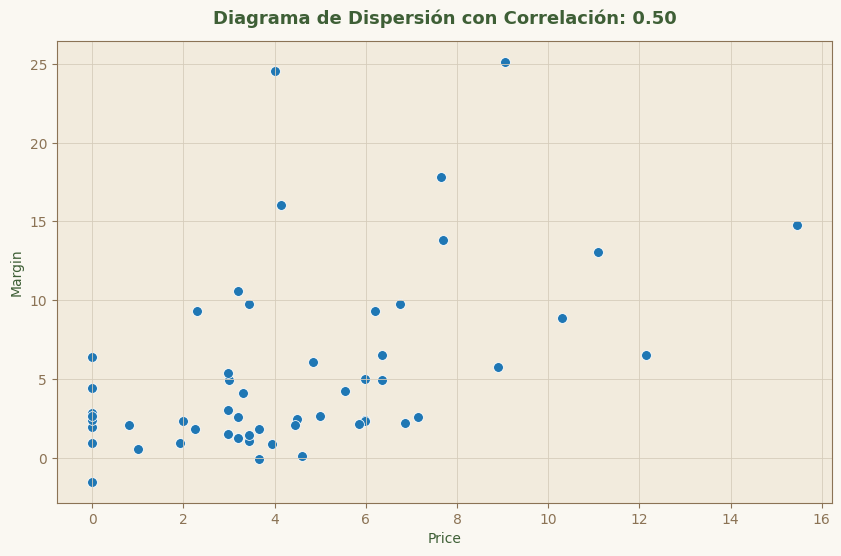

In [20]:
grafico_dispersion_con_correlacion(glovo, 'Price', 'Margin', mostrar_correlacion=True)

<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">Relación Precio vs Margen — Glovo</h2>

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Correlación: 0.50 (moderada positiva)</h3>

A mayor precio del producto, mayor margen absoluto generado.

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Conclusiones</h3>
- La correlación de 0.50 indica una relación moderada, no perfecta. El precio no es el único factor que determina el margen.
- Los productos de precio bajo (0-2€) generan márgenes muy bajos o incluso negativos.
- Los outliers más rentables (margen > 15€) corresponden a productos de precio medio-alto (4-9€).
- Hay bastante dispersión en productos de precio 3-5€, el margen depende más del coste que del precio.

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Recomendación</h3>
Priorizar en el catálogo de Glovo productos de precio medio-alto (4-10€) ya que tienen mejor relación precio-margen.


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">4.8 Margen por categoría</h3>

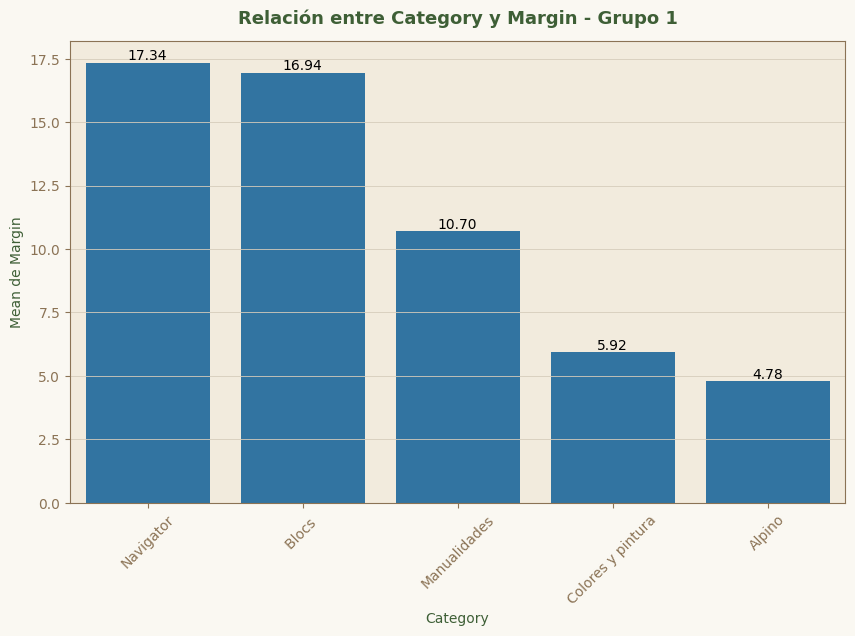

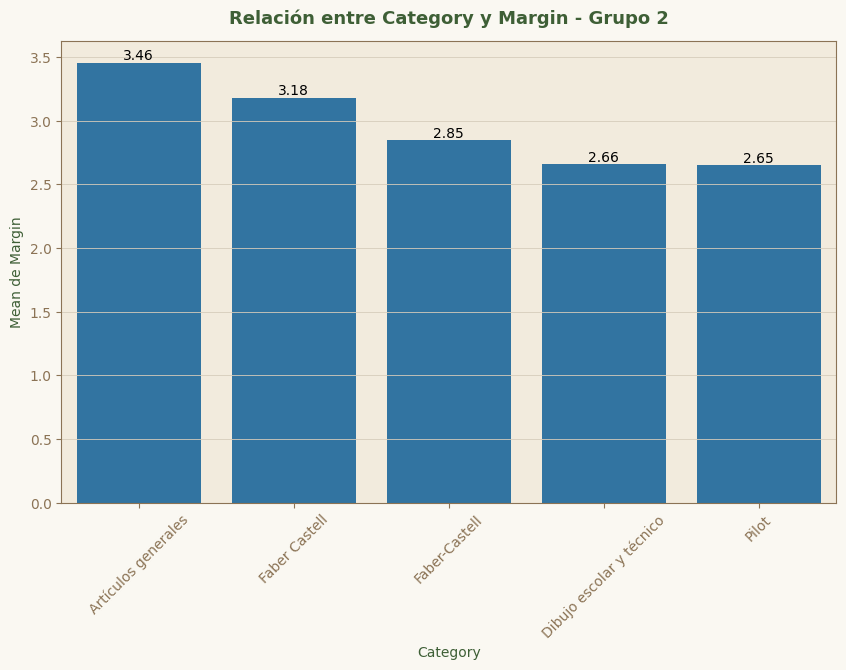

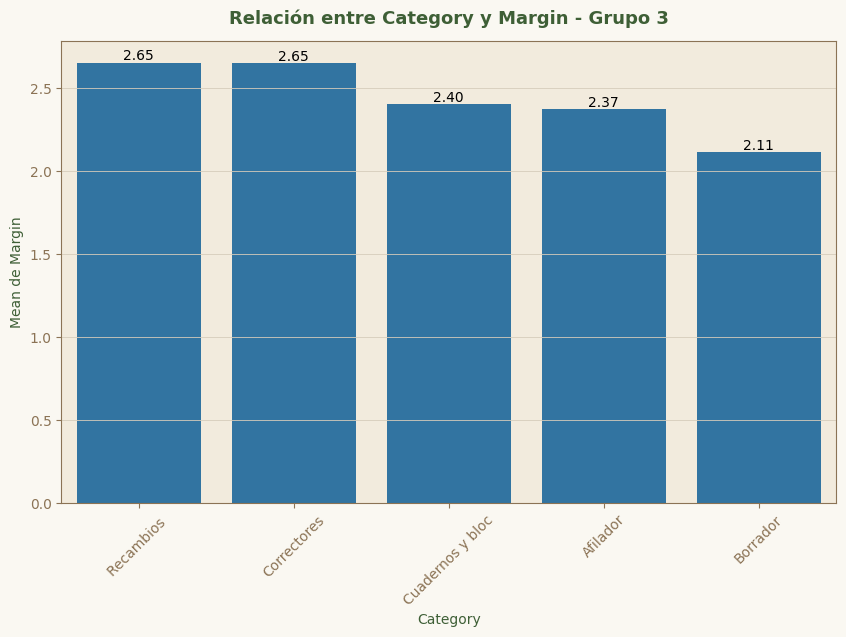

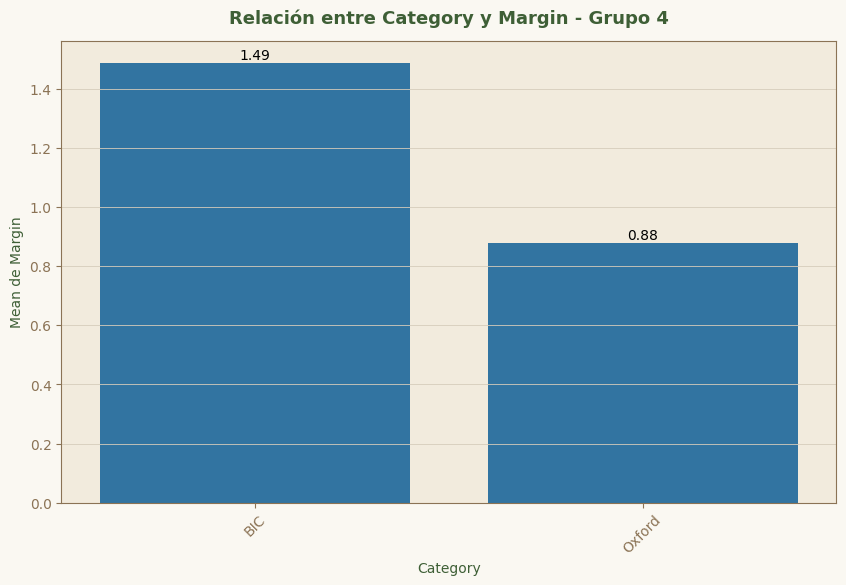

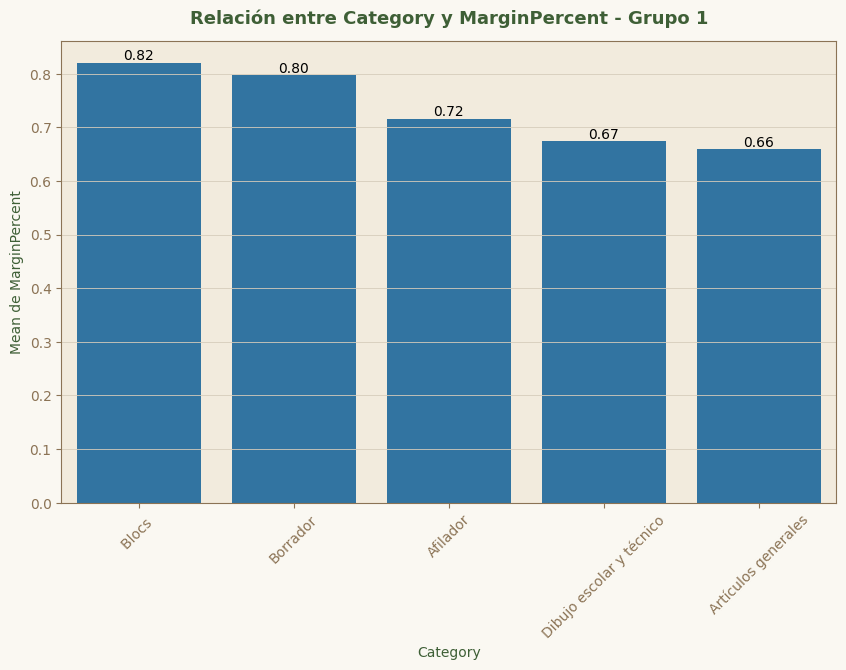

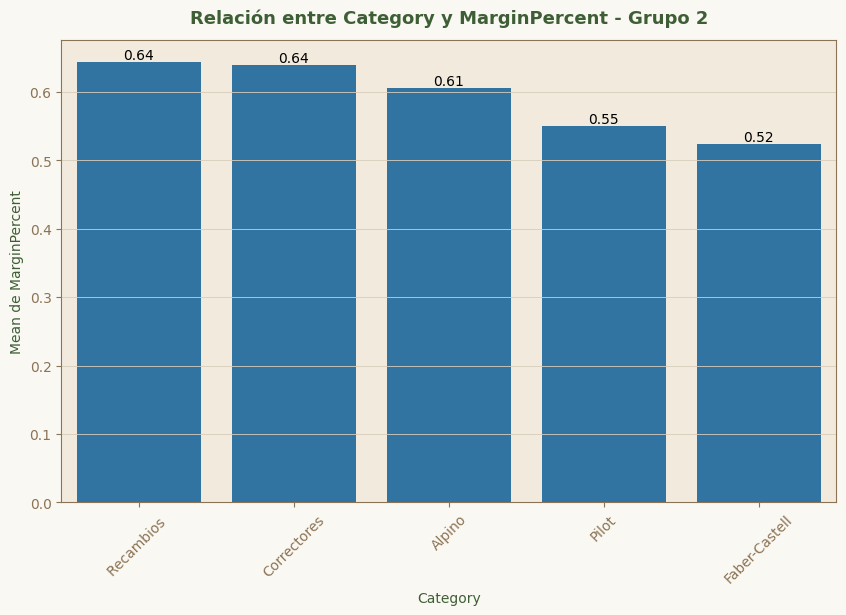

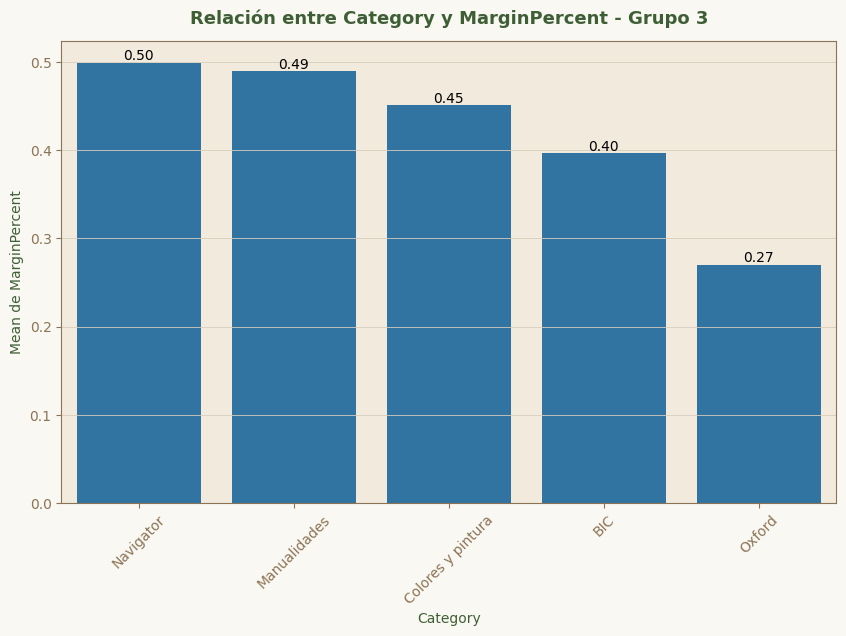

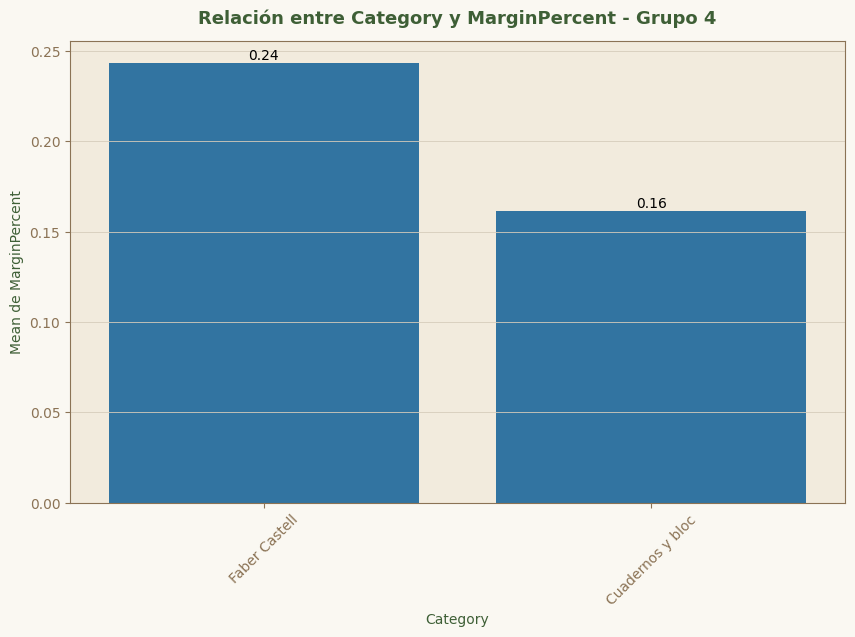

In [21]:
plot_categorical_numerical_relationship(glovo, 'Category', 'Margin', show_values=True)
plot_categorical_numerical_relationship(glovo, 'Category', 'MarginPercent', show_values=True)


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">4.9 Matriz de correlación</h3>

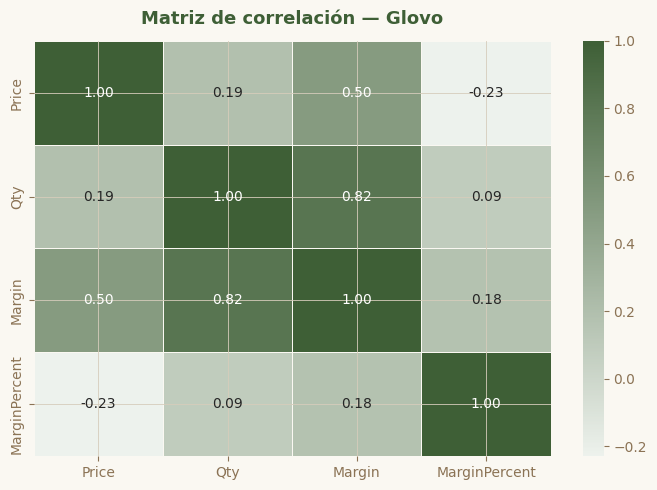

In [22]:
cmap_corr = sns.light_palette(C_PRINCIPAL, as_cmap=True)

plt.figure(figsize=(7, 5))
sns.heatmap(glovo[['Price', 'Qty', 'Margin', 'MarginPercent']].corr(),
            annot=True, fmt='.2f', cmap=cmap_corr,
            linewidths=0.5, linecolor=C_BLANCO)
plt.title('Matriz de correlación — Glovo')
plt.tight_layout()
plt.show()


<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">Matriz de correlación — Glovo</h2>

| Par de variables | Correlación | Interpretación |
|---|---|---|
| Qty → Margin | 0.82 | Fuerte positiva |
| Price → Margin | 0.50 | Moderada positiva |
| Price → Qty | 0.19 | Muy débil |
| Price → MarginPercent | -0.23 | Débil negativa |

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Conclusiones</h3>
- **Qty → Margin (0.82):** Cuantas más unidades se venden, mayor es el margen absoluto.
- **Price → Margin (0.50):** Los productos más caros generan más margen en €, pero no de forma determinante.
- **Price → MarginPercent (-0.23):** Los productos más caros no tienen necesariamente mejor % de margen.

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Recomendación</h3>
Para maximizar el margen en Glovo hay que enfocarse en **vender más unidades** de los productos que ya tienen buen margen %, no necesariamente en subir precios.


---
<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">5. Comparativa Tienda física vs Glovo</h2>

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">5.1 Distribución de ventas por producto y canal</h3>

In [23]:
eat_in   = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Eat in'].groupby('Producto')['Cantidad'].sum()
take_out = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Take Out'].groupby('Producto')['Cantidad'].sum()

comparativa = pd.DataFrame({'Tienda': eat_in, 'Glovo': take_out}).fillna(0)
comparativa = comparativa[(comparativa['Tienda'] > 0) & (comparativa['Glovo'] > 0)]
comparativa['Total']    = comparativa['Tienda'] + comparativa['Glovo']
comparativa['%_Tienda'] = (comparativa['Tienda'] / comparativa['Total'] * 100).round(1)
comparativa['%_Glovo']  = (comparativa['Glovo']  / comparativa['Total'] * 100).round(1)

comparativa_sorted = comparativa.sort_values('%_Glovo', ascending=True).reset_index()
comparativa_sorted


,Producto,Tienda,Glovo,Total,%_Tienda,%_Glovo
0,Pegamento Barra Pritt 20g,41.0,1.0,42.0,97.6,2.4
1,Tippex Pocket Mouse 10m,39.0,1.0,40.0,97.5,2.5
2,TippEx Micro tape Twist,34.0,1.0,35.0,97.1,2.9
3,Borrable Frixion clicker 0.7 Azul,30.0,1.0,31.0,96.8,3.2
4,G2 0.7 Azul,29.0,1.0,30.0,96.7,3.3
5,Espiral A4 Cuadriculado 4x4,21.0,1.0,22.0,95.5,4.5
6,Pegamento Barra Pritt 11g,44.0,3.0,47.0,93.6,6.4
7,Borrable Frixion Ball 0.7 Azul,14.0,1.0,15.0,93.3,6.7
8,Pizarra Velleda Azul,12.0,1.0,13.0,92.3,7.7
9,Pizarra Velleda Negro,10.0,1.0,11.0,90.9,9.1


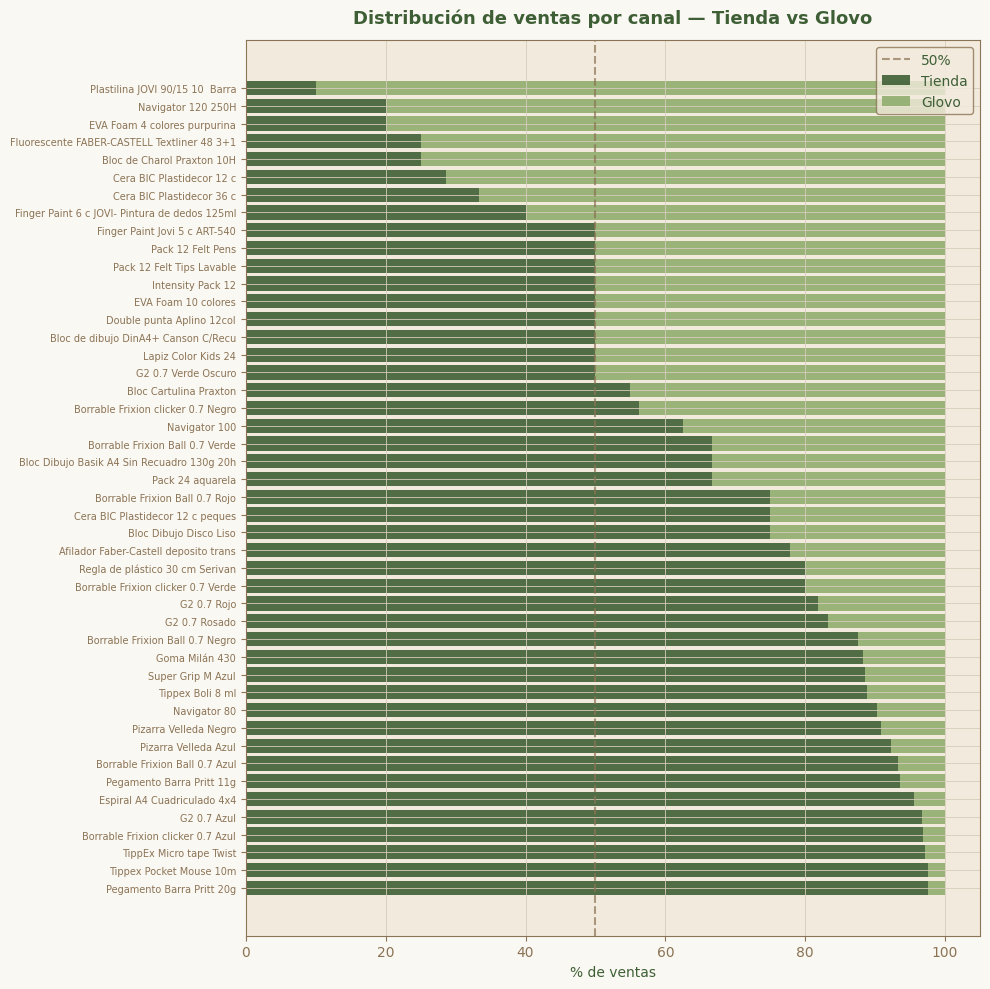

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))

categorias = comparativa_sorted.index
pct_tienda = comparativa_sorted['%_Tienda']
pct_glovo  = comparativa_sorted['%_Glovo']

ax.barh(categorias, pct_tienda, color=C_PRINCIPAL, label='Tienda', alpha=0.9)
ax.barh(categorias, pct_glovo,  left=pct_tienda, color=C_HOJA, label='Glovo', alpha=0.9)

ax.axvline(50, color=C_TIERRA, lw=1.5, ls='--', alpha=0.7, label='50%')
ax.set_xlabel('% de ventas')
ax.set_title('Distribución de ventas por canal — Tienda vs Glovo')
ax.legend()

ax.set_yticks(range(len(categorias)))
ax.set_yticklabels(comparativa_sorted['Producto'], fontsize=7)

plt.tight_layout()
plt.show()


<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">Comparativa de ventas por canal — Tienda vs Glovo</h2>

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Productos con mayor peso en Glovo</h3>
- **Plastilina JOVI 90/15 10 Barra** — 90% Glovo vs 10% Tienda.
- **EVA Foam 4 colores purpurina** y **Navigator 120 250H** — 80% Glovo.
- **Fluorescente FABER-CASTELL** y **Bloc de Charol Praxton 10H** — 75% Glovo.

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Productos equilibrados entre canales (50/50)</h3>
- EVA Foam 10 colores, Finger Paint, Bloc Canson, G2 0.7 Verde, entre otros.

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Productos con mayor peso en Tienda física</h3>
- **Pegamento Barra Pritt 20g** — 97.6% Tienda.
- **Tippex Pocket Mouse** — 97.5% Tienda.
- **Navigator 80** — 90.3% Tienda, a pesar de ser el más vendido en volumen total.

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Conclusiones</h3>
- Los productos de **manualidades y colores** tienen mucho más peso en Glovo.
- Los productos de **oficina y escritura** se compran principalmente en tienda.
- **Navigator 80** podría potenciarse en Glovo.


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">5.2 Métricas clave por canal</h3>

In [25]:
margen_tienda    = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Eat in']['Margen'].sum()
ventas_tienda    = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Eat in']['Ventas NETAS'].sum()
margen_glovo_v   = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Take Out']['Margen'].sum()
ventas_glovo_v   = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Take Out']['Ventas NETAS'].sum()
ticket_tienda    = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Eat in']['Ventas NETAS'].mean()
ticket_glovo_v   = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Take Out']['Ventas NETAS'].mean()
trans_tienda     = len(ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Eat in'])
trans_glovo      = len(ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Take Out'])

print(f'{"Métrica":<20} {"Tienda":>12} {"Glovo":>12}')
print('-' * 46)
print(f'{"Ventas totales":<20} {ventas_tienda:>11.0f}€ {ventas_glovo_v:>11.0f}€')
print(f'{"Margen total":<20} {margen_tienda:>11.0f}€ {margen_glovo_v:>11.0f}€')
print(f'{"% Margen":<20} {margen_tienda/ventas_tienda*100:>10.1f}% {margen_glovo_v/ventas_glovo_v*100:>10.1f}%')
print(f'{"Ticket medio":<20} {ticket_tienda:>11.2f}€ {ticket_glovo_v:>11.2f}€')
print(f'{"Transacciones":<20} {trans_tienda:>12} {trans_glovo:>12}')


Métrica                    Tienda        Glovo
----------------------------------------------
Ventas totales             14135€         602€
Margen total                7942€         304€
% Margen                   56.2%       50.5%
Ticket medio                1.89€        4.67€
Transacciones                7486          129


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">5.3 Test Mann-Whitney — ¿Diferencia significativa en márgenes?</h3>

In [26]:
tienda_margen = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Eat in']['Margen']
glovo_margen  = ventas[ventas['Comida para consumir en el Lugar o para Llevar'] == 'Take Out']['Margen']

stat, p_valor = mannwhitneyu(tienda_margen, glovo_margen)
print(f'P-valor: {p_valor:.4f}')

if p_valor < 0.05:
    print('✅ Diferencia estadísticamente significativa entre los márgenes de ambos canales')
else:
    print('❌ No hay diferencia significativa entre los márgenes')


P-valor: 0.0000
✅ Diferencia estadísticamente significativa entre los márgenes de ambos canales


<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">¿Es rentable Glovo? — Conclusiones</h2>

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Comparativa de métricas clave</h3>

| Métrica | Tienda | Glovo |
|---|---|---|
| Ventas totales | 14.134€ | 601€ |
| Margen total | 7.942€ | 303€ |
| % Margen | 56.2% | 50.5% |
| Ticket medio | 1.89€ | 4.67€ |
| Transacciones | 7.486 | 129 |

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Conclusiones</h3>

**Glovo SÍ es rentable pero es un canal secundario:**
- El margen % de Glovo (50.5%) es ligeramente inferior al de tienda (56.2%), pero sigue siendo muy bueno.
- El ticket medio de Glovo (4.67€) es **2.5 veces mayor** que el de tienda (1.89€).
- Sin embargo el volumen es muy bajo: solo 129 transacciones vs 7.486 de tienda, apenas el **1.7% del total**.

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Recomendación</h3>
Glovo es rentable y tiene un ticket medio alto, pero está muy infrautilizado.
Potenciar el canal con más productos y visibilidad podría incrementar ingresos
sin apenas coste adicional, ya que la infraestructura ya está montada.
